In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [23]:
df = pd.read_excel("A_list_of_OR_For_Neurosciences_xlsx.xlsx")
df.head()

,YEAR_G,MONTH_G,SEX,NATIONALITY,MARITAL_TYPE,REGION,DEPARTMENT_NAME,LOC_FACILITY_CD_DESC
0,2025,1,Female,Saudi,Single,Eastern Region,Neurosciences,KFSH&RC Riyadh
1,2025,1,Female,Saudi,Widowed,Central Region,Neurosciences,KFSH&RC Riyadh
2,2025,1,Male,Saudi,Married,Central Region,Neurosciences,KFSH&RC Riyadh
3,2025,2,Male,Saudi,Single,Central Region,Neurosciences,KFSH&RC Riyadh
4,2025,3,Female,Saudi,Married,Central Region,Neurosciences,KFSH&RC Riyadh


In [24]:
invalid_values = ["", "Unknown", "unknown", "UNKNOWN", "Undefined", "UNDEFINED"]
df_clean = df[~df["REGION"].isin(invalid_values) & df["REGION"].notna()].copy()


In [25]:
# Convert text/categorical columns to 'category' dtype (like as.factor in R)
cat_cols = df.select_dtypes(include="object").columns
df[cat_cols] = df[cat_cols].astype("category")

In [26]:
summary_table = df_clean.describe(include="all").T
print(summary_table)

                      count unique             top freq     mean      std  \
YEAR_G                725.0    NaN             NaN  NaN   2025.0      0.0   
MONTH_G               725.0    NaN             NaN  NaN  1.89931  0.80025   
SEX                     725      2            Male  399      NaN      NaN   
NATIONALITY             725      2           Saudi  698      NaN      NaN   
MARITAL_TYPE            725      6          Single  455      NaN      NaN   
REGION                  725      5  Central Region  240      NaN      NaN   
DEPARTMENT_NAME         725      1   Neurosciences  725      NaN      NaN   
LOC_FACILITY_CD_DESC    725      3  KFSH&RC Riyadh  509      NaN      NaN   

                         min     25%     50%     75%     max  
YEAR_G                2025.0  2025.0  2025.0  2025.0  2025.0  
MONTH_G                  1.0     1.0     2.0     3.0     3.0  
SEX                      NaN     NaN     NaN     NaN     NaN  
NATIONALITY              NaN     NaN     NaN     NaN  

In [27]:
region_table = df_clean["REGION"].value_counts()
print("\nRegion Distribution:")
print(region_table)


Region Distribution:
REGION
Central Region     240
Western Region     210
Southern Region    120
Northern Region     82
Eastern Region      73
Name: count, dtype: int64


In [28]:
facility_table = df["LOC_FACILITY_CD_DESC"].value_counts()
print("\nFacility Distribution:")
print(facility_table)


Facility Distribution:
LOC_FACILITY_CD_DESC
KFSH&RC Riyadh     533
KFSH&RC Jeddah     201
KFSH&RC MADINAH     15
Name: count, dtype: int64


In [29]:
region_counts = (
    df_clean.groupby("REGION", observed=True)
    .size()
    .reset_index(name="Number_of_Operations")
    .sort_values("Number_of_Operations", ascending=False)
)
print("\nOperations by Region:")
print(region_counts)


Operations by Region:
            REGION  Number_of_Operations
0   Central Region                   240
4   Western Region                   210
3  Southern Region                   120
2  Northern Region                    82
1   Eastern Region                    73


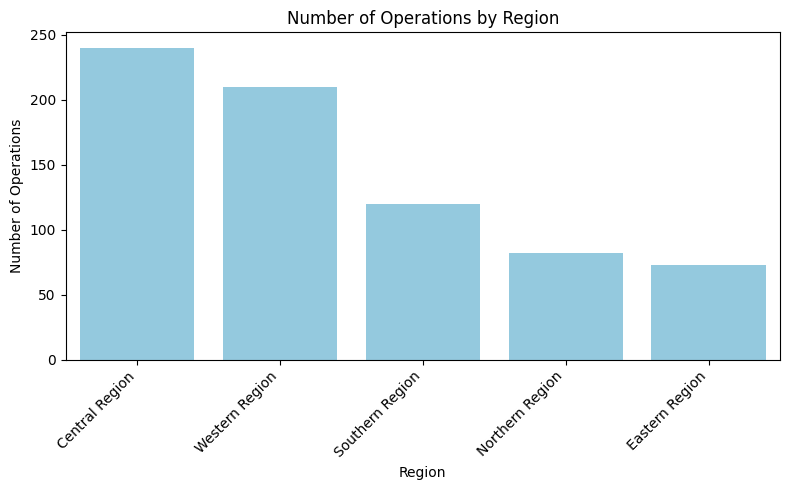

In [30]:
plt.figure(figsize=(8, 5))
sns.barplot(data=region_counts, x="REGION", y="Number_of_Operations", color="skyblue")
plt.title("Number of Operations by Region")
plt.xlabel("Region")
plt.ylabel("Number of Operations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("operations_by_region.png", dpi=150)
plt.show()

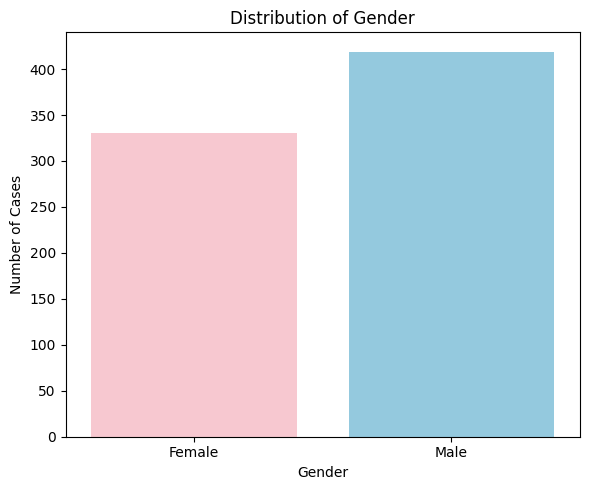

In [31]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="SEX", hue="SEX", palette={"Female": "pink", "Male": "skyblue"}, legend=False)
plt.title("Distribution of Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Cases")
plt.tight_layout()
plt.savefig("gender_distribution.png", dpi=150)
plt.show()

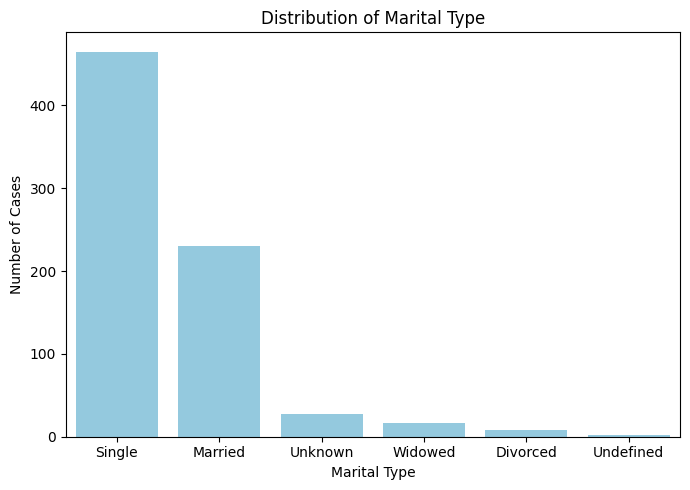

In [32]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="MARITAL_TYPE", color="skyblue",
              order=df["MARITAL_TYPE"].value_counts().index)
plt.title("Distribution of Marital Type")
plt.xlabel("Marital Type")
plt.ylabel("Number of Cases")
plt.tight_layout()
plt.savefig("marital_distribution.png", dpi=150)
plt.show()

In [33]:
# H0: No significant difference in mean monthly operations across regions
# Ha: There IS a significant difference

monthly_counts = (
    df_clean.groupby(["REGION", "MONTH_G"], observed=True)
    .size()
    .reset_index(name="Operations")
)

model = ols("Operations ~ C(REGION)", data=monthly_counts).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("\nANOVA Results:")
print(anova_table)

f_stat = anova_table["F"].iloc[0]
p_value = anova_table["PR(>F)"].iloc[0]
print(f"\nF = {f_stat:.2f}, p = {p_value:.6f}")

if p_value < 0.05:
    print("=> Reject H0: significant difference between regions")
else:
    print("=> Fail to reject H0: no significant difference between regions")


ANOVA Results:
                sum_sq    df          F    PR(>F)
C(REGION)  7676.000000   4.0  17.392749  0.000168
Residual   1103.333333  10.0        NaN       NaN

F = 17.39, p = 0.000168
=> Reject H0: significant difference between regions


In [34]:
tukey_result = pairwise_tukeyhsd(
    endog=monthly_counts["Operations"],
    groups=monthly_counts["REGION"],
    alpha=0.05
)
print("\nTukey HSD Results:")
print(tukey_result)


Tukey HSD Results:
          Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1          group2     meandiff p-adj   lower    upper   reject
------------------------------------------------------------------------
 Central Region  Eastern Region -55.6667 0.0005 -83.8925 -27.4409   True
 Central Region Northern Region -52.6667 0.0008 -80.8925 -24.4409   True
 Central Region Southern Region    -40.0 0.0062 -68.2258 -11.7742   True
 Central Region  Western Region    -10.0 0.7696 -38.2258  18.2258  False
 Eastern Region Northern Region      3.0 0.9962 -25.2258  31.2258  False
 Eastern Region Southern Region  15.6667 0.4107 -12.5591  43.8925  False
 Eastern Region  Western Region  45.6667 0.0024  17.4409  73.8925   True
Northern Region Southern Region  12.6667 0.5976 -15.5591  40.8925  False
Northern Region  Western Region  42.6667 0.0039  14.4409  70.8925   True
Southern Region  Western Region     30.0 0.0363   1.7742  58.2258   True
-------------------------------

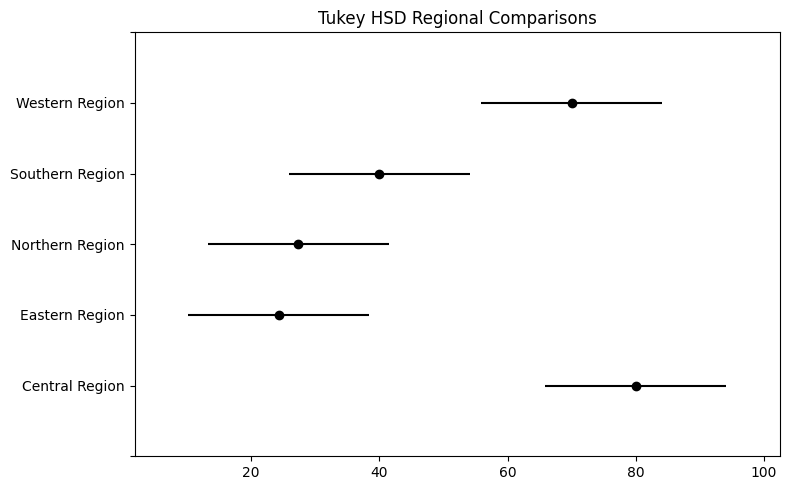

In [35]:
fig = tukey_result.plot_simultaneous(figsize=(8, 5))
plt.title("Tukey HSD Regional Comparisons")
plt.tight_layout()
plt.savefig("tukey_hsd.png", dpi=150)
plt.show()

In [36]:
population = {
     "Central Region": 8_800_000,
     "Western Region": 7_800_000,
     "Eastern Region": 5_200_000,
     "Southern Region": 3_500_000,
     "Northern Region": 1_600_000,
 }

region_counts["Population"] = region_counts["REGION"].map(population)
region_counts["Operations_per_100k"] = (
     region_counts["Number_of_Operations"] / region_counts["Population"] * 100_000
 )
print(region_counts[["REGION", "Number_of_Operations", "Operations_per_100k"]])

            REGION  Number_of_Operations  Operations_per_100k
0   Central Region                   240             2.727273
4   Western Region                   210             2.692308
3  Southern Region                   120             3.428571
2  Northern Region                    82             5.125000
1   Eastern Region                    73             1.403846
